# Feature Engineering – Data Science Salary Prediction

In this notebook we prepare the dataset for machine learning by:

- Creating the target variable (log_salary)
- Encoding categorical variables
- Selecting relevant features
- Splitting data for modeling

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/ds_salaries_2025_clean.csv")

Text(0.5, 1.0, 'Log Salary Distribution')

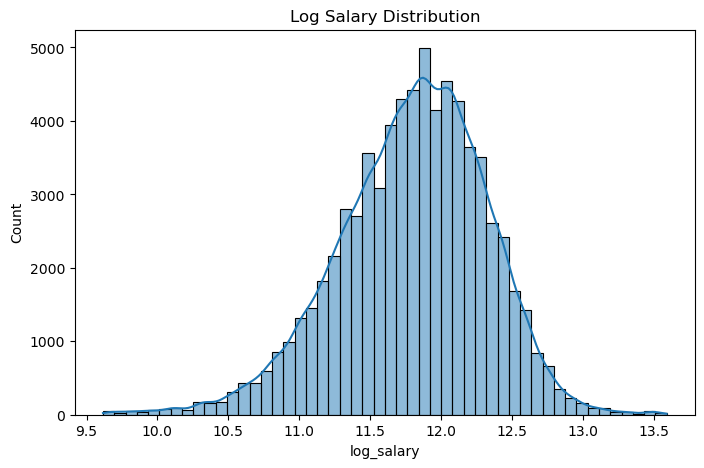

In [38]:
df["log_salary"] = np.log1p(df["salary_in_usd"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_salary"], bins=50, kde=True)
plt.title("Log Salary Distribution")

In [39]:
df = df.drop(columns=["salary", "salary_currency", "salary_in_usd"])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   work_year         71913 non-null  int64  
 1   experience_level  71913 non-null  int64  
 2   employment_type   71913 non-null  object 
 3   job_title         71913 non-null  object 
 4   remote_ratio      71913 non-null  int64  
 5   company_size      71913 non-null  int64  
 6   log_salary        71913 non-null  float64
 7   company_region    71913 non-null  object 
 8   employee_region   71913 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 4.9+ MB


In [47]:
df.select_dtypes(include="object").nunique()

employment_type      4
job_title          422
company_region       4
employee_region      4
dtype: int64

In [42]:
# Target Variable
y = df["log_salary"]
X = df.drop("log_salary", axis=1)

In [43]:
# For the columns which have NATURAL order
# experience_level and company_size
# Mapping remote_ratio back to its original value for modelling


experience_map = {
    "Entry":0,
    "Mid":1,
    "Senior":2,
    "Executive":3
}

df["experience_level"] = df["experience_level"].map(experience_map)

size_map = {
    "Small":0,
    "Medium":1,
    "Large":2
}

df["company_size"] = df["company_size"].map(size_map)

remote_map_rev = {
    "Onsite":0,
    "Hybrid":50,
    "Remote":100
}

df["remote_ratio"] = df["remote_ratio"].map(remote_map_rev)

Following feature columns have very high cardinality:

- job_title --> 422
- employee_residence --> 104
- company_location --> 97

So to reduce their cardinality and 

In [44]:
us = ["US"]
europe = ["DE","GB","FR","ES","IT","NL"]
asia = ["IN","CN","JP","SG"]

def map_region(country):
    if country in us:
        return "US"
    elif country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    else:
        return "Other"

df["company_region"] = df["company_location"].apply(map_region)
df["employee_region"] = df["employee_residence"].apply(map_region)

In [45]:
df.drop("employee_residence", axis=1, inplace=True)
df.drop("company_location", axis=1, inplace=True)

In [56]:
df.select_dtypes(include="object").nunique()

Series([], dtype: float64)

In [49]:
df["job_title"].value_counts().head(20)

job_title
Data Scientist               7160
Data Engineer                7071
Data Analyst                 6405
Software Engineer            4921
Engineer                     4375
Manager                      3612
Machine Learning Engineer    3462
Analyst                      2783
Research Scientist           1381
Analytics Engineer           1341
Product Manager              1326
Associate                    1238
Data Architect               1231
AI Engineer                  1163
Research Engineer             887
Consultant                    783
Developer                     715
Data Manager                  697
Data Specialist               669
Systems Engineer              563
Name: count, dtype: int64

In [50]:
top_jobs = df["job_title"].value_counts().head(20).index

df["job_title"] = df["job_title"].where(
    df["job_title"].isin(top_jobs),
    "Other"
)

In [53]:
df = pd.get_dummies(
    df,
    columns=["employment_type", "job_title", "company_region", "employee_region"],
    drop_first=True
)

In [54]:
df.head()


,work_year,experience_level,remote_ratio,company_size,log_salary,employment_type_Freelance,employment_type_Full-time,employment_type_Part-time,job_title_Analyst,job_title_Analytics Engineer,...,job_title_Research Engineer,job_title_Research Scientist,job_title_Software Engineer,job_title_Systems Engineer,company_region_Europe,company_region_Other,company_region_US,employee_region_Europe,employee_region_Other,employee_region_US
0,2025,3,0,1,12.761442,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2025,3,0,1,12.355979,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,2025,2,0,1,11.887251,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,2025,2,0,1,11.309597,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,2025,1,100,1,11.982935,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [55]:
df.dtypes

work_year                                int64
experience_level                         int64
remote_ratio                             int64
company_size                             int64
log_salary                             float64
employment_type_Freelance                 bool
employment_type_Full-time                 bool
employment_type_Part-time                 bool
job_title_Analyst                         bool
job_title_Analytics Engineer              bool
job_title_Associate                       bool
job_title_Consultant                      bool
job_title_Data Analyst                    bool
job_title_Data Architect                  bool
job_title_Data Engineer                   bool
job_title_Data Manager                    bool
job_title_Data Scientist                  bool
job_title_Data Specialist                 bool
job_title_Developer                       bool
job_title_Engineer                        bool
job_title_Machine Learning Engineer       bool
job_title_Man